Логарифмическое степенное преобразование и преобразование в негатив

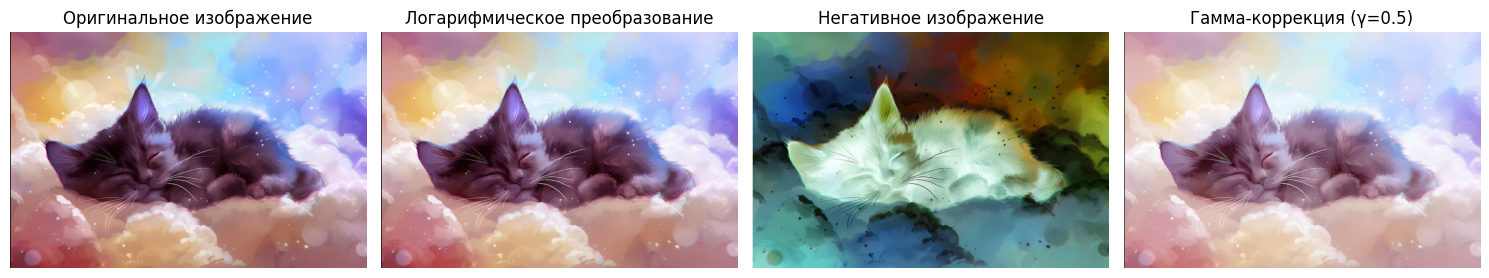

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Загрузка изображения
img = cv2.imread('kitten.png')

# Нормализация изображения для избежания переполнения
img_normalized = img.astype(np.float32) / 255.0

# Логарифмическое преобразование
# Добавляем маленькое значение к избежания log(0)
log_img = np.log(1.0 + img_normalized)
# Масштабируем к диапазону [0, 255]
log_img = (255 * log_img / np.max(log_img)).astype(np.uint8)

# Негативное преобразование
negative_img = 255 - img

# Гамма-коррекция
gamma = 0.5
gamma_img = (255 * np.power(img_normalized, gamma)).astype(np.uint8)

# Отображение результатов
plt.figure(figsize=(15, 10))

# Оригинальное изображение
plt.subplot(1, 4, 1)
plt.imshow(img, vmin=0, vmax=255)
plt.title('Оригинальное изображение')
plt.axis('off')

# Логарифмическое преобразование
plt.subplot(1, 4, 2)
plt.imshow(log_img, vmin=0, vmax=255)
plt.title('Логарифмическое преобразование')
plt.axis('off')

# Негативное изображение
plt.subplot(1, 4, 3)
plt.imshow(negative_img, vmin=0, vmax=255)
plt.title('Негативное изображение')
plt.axis('off')

# Гамма-коррекция
plt.subplot(1, 4, 4)
plt.imshow(gamma_img, vmin=0, vmax=255)
plt.title('Гамма-коррекция (γ=0.5)')
plt.axis('off')

plt.tight_layout()
plt.show()

Фильтр нерезкого маскирования

/tmp/ipython-input-49986000.py:66: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 60 negative Z values that have been clipped to zero
  sharpened_rgb_array = color.lab2rgb(sharpened_lab_array)


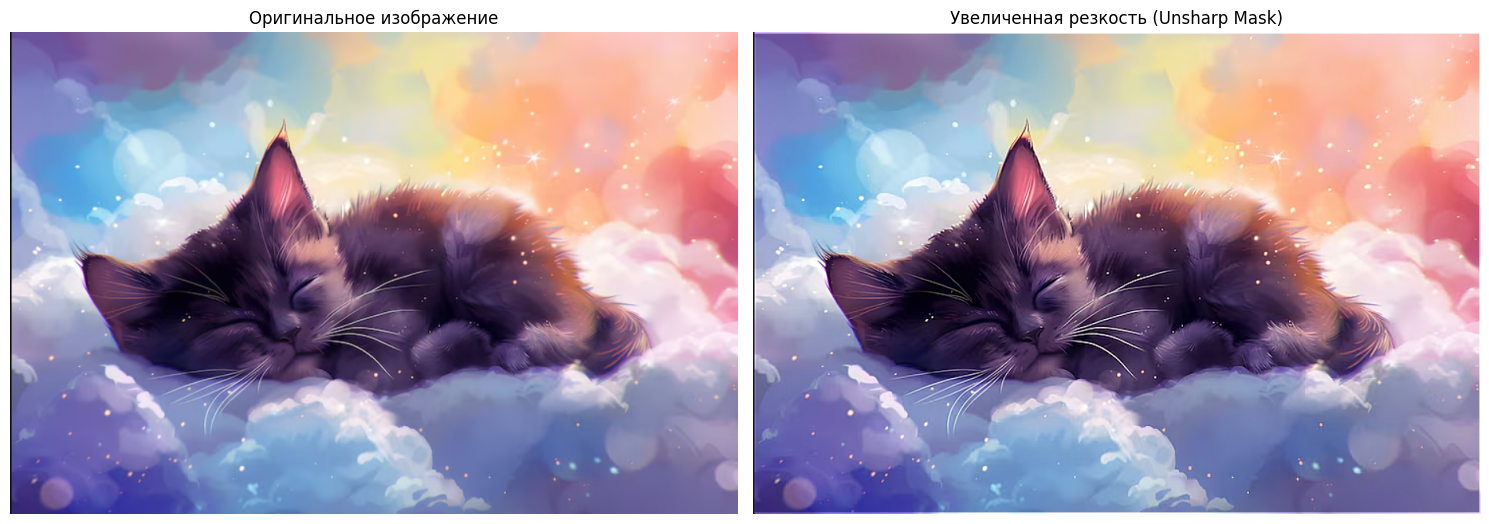

In [22]:
from PIL import Image
from numpy import *
from skimage import color
import matplotlib.pyplot as plt

def gaussian_blur(image_array, m_size, sigma):
    """
    Применяет гауссово размытие к изображению
    :param image_array: массив изображения (только L-канал)
    :param m_size: размер ядра фильтра (нечетное число)
    :param sigma: параметр размытия (стандартное отклонение)
    :return: размытое изображение
    """
    # Создаем гауссово ядро
    matrix = zeros((m_size, m_size))
    center = m_size // 2  # Центр ядра

    # Заполняем ядро значениями гауссовой функции
    for i in range(m_size):
        for j in range(m_size):
            distance = sqrt((i - center) ** 2 + (j - center) ** 2)  # Расстояние от центра
            matrix[i, j] = exp((-distance ** 2) / (2 * sigma ** 2))  # Гауссова функция

    # Нормализуем ядро (сумма всех элементов = 1)
    matrix /= sum(matrix)

    # Применяем свертку - гауссово размытие
    blur_array = zeros_like(image_array)
    for i in range(center, image_array.shape[0] - center):
        for j in range(center, image_array.shape[1] - center):
            # Вычисляем взвешенное среднее для каждого пикселя
            average = sum(image_array[i - center:i + center + 1, j - center:j + center + 1] * matrix)
            blur_array[i, j] = average

    return blur_array

def unsharp_mask(image_array, m_size, sigma, amount, threshold):
    """
    Применяет маску нерезкости для повышения резкости изображения
    :param image_array: массив изображения в LAB цветовом пространстве
    :param m_size: размер ядра гауссова фильтра
    :param sigma: параметр размытия
    :param amount: сила повышения резкости
    :param threshold: порог для применения маски
    :return: изображение с повышенной резкостью
    """
    # Размываем только L-канал (яркость)
    blurred_l = gaussian_blur(image_array[..., 0], m_size, sigma)

    # Вычисляем маску резкости (разница между оригиналом и размытым)
    l_mask = image_array[..., 0] - blurred_l

    # Применяем маску к оригинальному изображению
    sharpened_l_array = image_array[..., 0] + amount * l_mask

    # Применяем пороговую обработку - не усиливаем слабые края
    for i in range(image_array.shape[0]):
        for j in range(image_array.shape[1]):
            if abs(l_mask[i, j]) < threshold:
                sharpened_l_array[i, j] = image_array[i, j, 0]  # Оставляем оригинальное значение

    # Восстанавливаем LAB изображение с усиленным L-каналом
    sharpened_lab_array = stack((sharpened_l_array, image_array[..., 1], image_array[..., 2]), axis=-1)

    # Конвертируем обратно в RGB
    sharpened_rgb_array = color.lab2rgb(sharpened_lab_array)
    sharpened_rgb_array *= 255  # Масштабируем к [0, 255]

    # Создаем изображение из массива
    sharpened_image = Image.fromarray(sharpened_rgb_array.astype(uint8))
    return sharpened_image

# Основной код
# Загрузка и подготовка оригинального изображения
original = Image.open("kitten.png").convert('RGB')
original_array = array(original) / 255.0  # Нормализуем к [0, 1]

# Конвертируем в LAB цветовое пространство (L - яркость, A и B - цвет)
lab_array = color.rgb2lab(original_array)

# Параметры для маски нерезкости
m_size = 5     # Размер ядра (нечетное число)
sigma = 1.5    # Степень размытия
amount = 1     # Сила повышения резкости
threshold = 0.1  # Порог для применения маски

# Применяем маску нерезкости
sharpened_image = unsharp_mask(lab_array, m_size, sigma, amount, threshold)

# Отображение результатов в Google Colab
plt.figure(figsize=(15, 8))

# Оригинальное изображение
plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title('Оригинальное изображение')
plt.axis('off')

# Увеличенное изображение
plt.subplot(1, 2, 2)
plt.imshow(sharpened_image)
plt.title('Увеличенная резкость (Unsharp Mask)')
plt.axis('off')

plt.tight_layout()
plt.show()